<a href="https://colab.research.google.com/github/romanrudniev/MachineLearning/blob/main/%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
print(X_test)
print(y_test)

[[[[158 112  49]
   [159 111  47]
   [165 116  51]
   ...
   [137  95  36]
   [126  91  36]
   [116  85  33]]

  [[152 112  51]
   [151 110  40]
   [159 114  45]
   ...
   [136  95  31]
   [125  91  32]
   [119  88  34]]

  [[151 110  47]
   [151 109  33]
   [158 111  36]
   ...
   [139  98  34]
   [130  95  34]
   [120  89  33]]

  ...

  [[ 68 124 177]
   [ 42 100 148]
   [ 31  88 137]
   ...
   [ 38  97 146]
   [ 13  64 108]
   [ 40  85 127]]

  [[ 61 116 168]
   [ 49 102 148]
   [ 35  85 132]
   ...
   [ 26  82 130]
   [ 29  82 126]
   [ 20  64 107]]

  [[ 54 107 160]
   [ 56 105 149]
   [ 45  89 132]
   ...
   [ 24  77 124]
   [ 34  84 129]
   [ 21  67 110]]]


 [[[235 235 235]
   [231 231 231]
   [232 232 232]
   ...
   [233 233 233]
   [233 233 233]
   [232 232 232]]

  [[238 238 238]
   [235 235 235]
   [235 235 235]
   ...
   [236 236 236]
   [236 236 236]
   [235 235 235]]

  [[237 237 237]
   [234 234 234]
   [234 234 234]
   ...
   [235 235 235]
   [235 235 235]
   [234 234

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# Список назв класів українською мовою
class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64,  activation='relu'),

    layers.Dense(10,  activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
histoty = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4468 - loss: 1.5226 - val_accuracy: 0.5564 - val_loss: 1.2352
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5919 - loss: 1.1575 - val_accuracy: 0.6106 - val_loss: 1.0904
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6462 - loss: 1.0088 - val_accuracy: 0.6490 - val_loss: 1.0007
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6811 - loss: 0.9102 - val_accuracy: 0.6583 - val_loss: 0.9713
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7051 - loss: 0.8377 - val_accuracy: 0.6762 - val_loss: 0.9464
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7285 - loss: 0.7768 - val_accuracy: 0.6859 - val_loss: 0.8985
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7464 - loss: 0.7261 - val_accuracy: 0.6862 - val_loss: 0.9263
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7582 - loss: 0.6840 -

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nТочність на тестовому наборі: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7056 - loss: 0.8995

Точність на тестовому наборі: 0.71


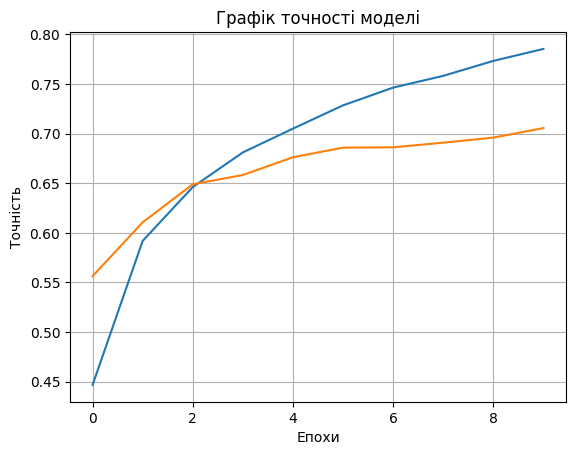

In [10]:
plt.plot(histoty.history['accuracy'])
plt.plot(histoty.history['val_accuracy'])
plt.xlabel("Епохи")
plt.ylabel("Точність")
plt.title("Графік точності моделі")
plt.grid(True)
plt.show()


In [11]:
def load_and_prepare_image(img):
  image = Image.open(img).convert("RGB")
  image = image.resize((32, 32))
  image_array = np.array(image) / 255.0
  image_array = np.expand_dims(image_array, axis=0)
  return image_array

In [12]:
custom_image_path = "кіт.jpg" #@param {type:"string"}

In [13]:
import os

if os.path.exists(custom_image_path):
  try:
    prepared_img = load_and_prepare_image(custom_image_path)
    prediction = model.predict(prepared_img)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Preed: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")
  except Exception as e:
    print(f"Error: {e}")
else:
  print(f"Not found file {custom_image_path}")

Not found file кіт.jpg


In [14]:
from google.colab import files

print("Upload file (JPG or PNG): ")
uploaded = files.upload()

Upload file (JPG or PNG): 


Saving потяг.jpg to потяг.jpg
Saving вантажівка.jpg to вантажівка.jpg
Saving корабель.jpg to корабель.jpg
Saving кінь.jpg to кінь.jpg
Saving жаба.jpg to жаба.jpg
Saving собака.jpg to собака.jpg
Saving олень.jpg to олень.jpg
Saving кіт.jpg to кіт.jpg
Saving птах.jpg to птах.jpg
Saving автомобіль.jpg to автомобіль.jpg
Saving літак.jpg to літак.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
Preed: 9 (вантажівка) - on 43.78%


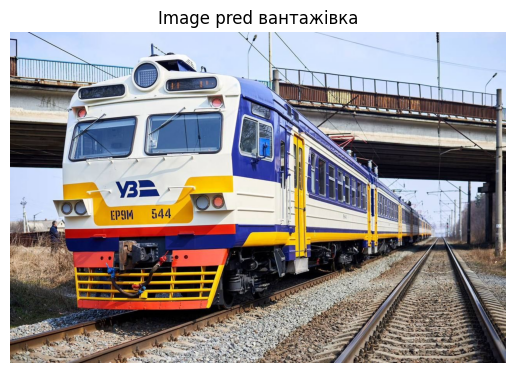

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Preed: 9 (вантажівка) - on 98.70%


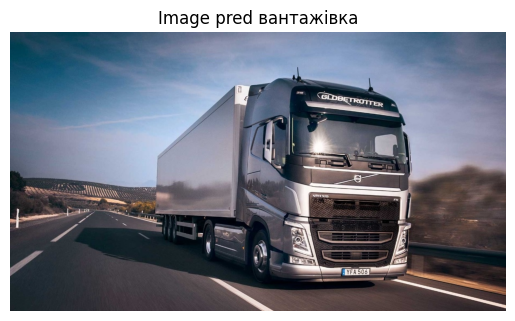

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Preed: 8 (корабель) - on 98.44%


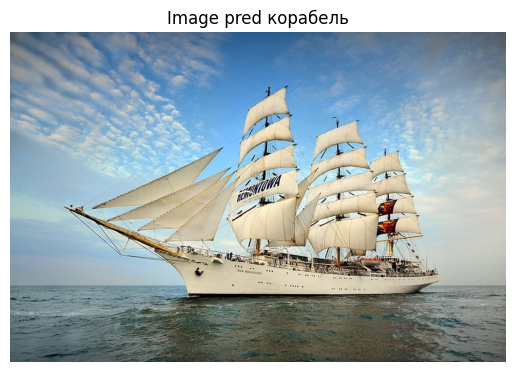

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Preed: 7 (кінь) - on 99.97%


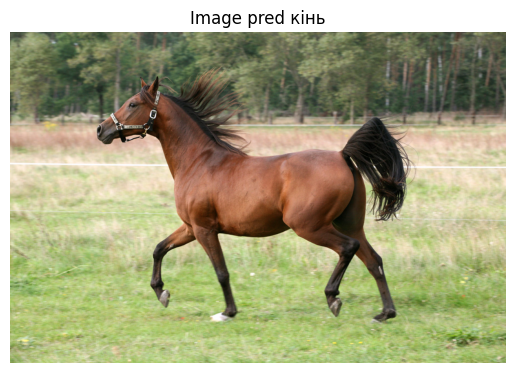

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Preed: 6 (жаба) - on 58.19%


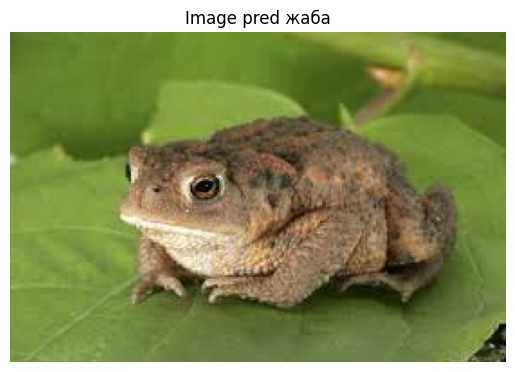

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Preed: 3 (кіт) - on 43.91%


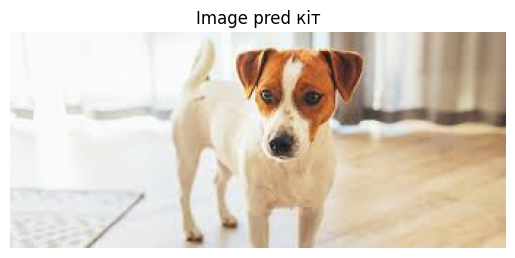

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Preed: 7 (кінь) - on 84.37%


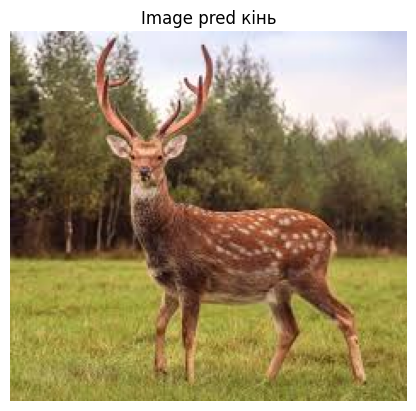

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Preed: 3 (кіт) - on 82.20%


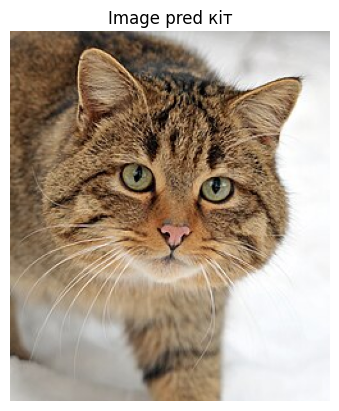

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Preed: 2 (птах) - on 90.51%


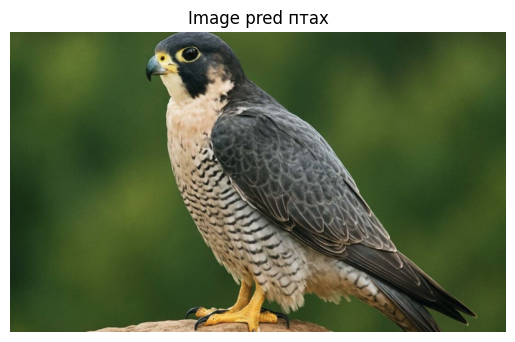

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Preed: 1 (автомобіль) - on 97.71%


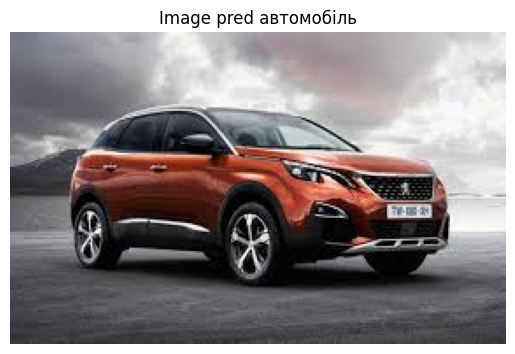

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Preed: 0 (літак) - on 84.95%


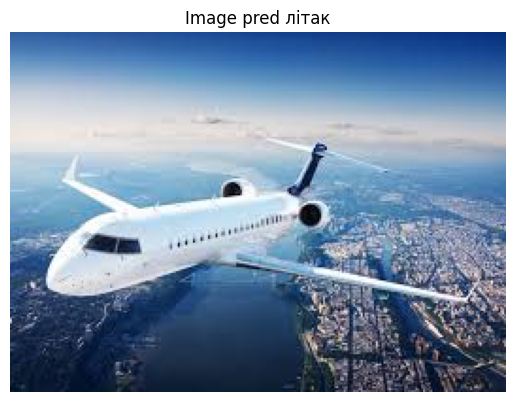

In [15]:
for f in uploaded.keys():
  img = f
  prepared_img = load_and_prepare_image(img)
  prediction = model.predict(prepared_img)
  predicted_class = np.argmax(prediction)
  confidence = np.max(prediction)

  print(f"Preed: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")

  img = Image.open(img)
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Image pred {class_name[predicted_class]}")
  plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

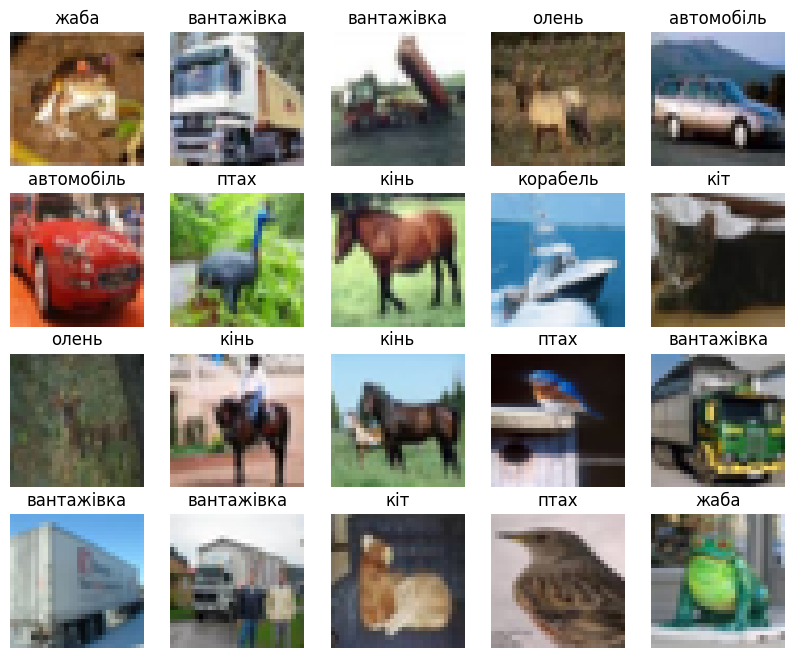

In [29]:
plt.figure(figsize=(10, 8))

for i in range(20):
  plt.subplot(4, 5, i + 1)
  plt.imshow(X_train[i])
  plt.title(class_name[y_train[i][0]])
  plt.axis('off')
plt.show